<table>
    <tr>
        <td style="text-align:left">
            <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9ItLTT_F-3Q30cu7ZCCoKmuFGBt22pe7pNA" alt="Logo Universidad" width="300"/>
        </td>
        <td>
            Departamento de Ciencias de la Computación y de la Decisión<br>
            Facultad de Minas<br>
            Universidad Nacional de Colombia<br>
            Optimizacion e IA 2026-2S<br><br>
            Estudiante: Juan Gabriel Carvajal Negrete<br>
            <br>
            Maestria En Ingenieria Analitica 
        </td>    
    </tr>
</table>

In [9]:
#--------------------- Importación de librerias -----------------------#
########################################################################

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
import numpy as np

## **Clasificación RandonForest sobre el conjunto de datos Digits.**

In [2]:
# Cargar la base de datos 
digit = datasets.load_digits()

# Revisamos categorias y columnas de la base de datos 
print(digit.target_names)
print(digit.feature_names)

[0 1 2 3 4 5 6 7 8 9]
['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']


In [3]:
# Construcción del objeto dataframe para el manejo comodo de los datos 

df_digit = pd.DataFrame(data=digit.data, columns=digit.feature_names)
df_digit["Etiqueta"] = digit.target

In [4]:
df_digit

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Etiqueta
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [5]:
# Dividimos los datos entre entrenamiento y prueba 
X = df_digit[df_digit.columns.difference(["Etiqueta"])]
Y = df_digit.Etiqueta

# Seleccionamos el conjunto de entrenamiento (70% del total de los datos) y el conjunto de prueba (30% d elos datos)
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **Optimización de hiperparametros usando busqueda de grilla**

Objetivo: encontrar la mejor combinación de hiperparámetros
para un RandomForestClassifier mediante búsqueda exhaustiva
por grilla (GridSearchCV)

In [11]:
#Creamos la grilla con los parametros a seleccionar
param_grid = {'n_estimators': np.arange(10,200,8),
              'criterion': ['gini','entropy'],
              'max_depth': [2,3,5,10,12,15,20]
}
#Defimos el clasificador base
base_estimator = RandomForestClassifier()
#Realizamos la busqueda de los hiperparametros
RF_gridSearch = GridSearchCV(base_estimator, param_grid)
#Nota: no se olviden de invocar el metodo para entrenar .fit
RF_gridSearch.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 10, 12, 15, 20],
                         'n_estimators': array([ 10,  18,  26,  34,  42,  50,  58,  66,  74,  82,  90,  98, 106,
       114, 122, 130, 138, 146, 154, 162, 170, 178, 186, 194])})

In [12]:
# parametros sleecionados por el método

RF_gridSearch.best_params_


{'criterion': 'entropy', 'max_depth': 20, 'n_estimators': np.int64(90)}

In [13]:
#Usamos el clasificador y analizamos su precision
y_pred = RF_gridSearch.best_estimator_.predict(X_test)
print("Accuracy : "), metrics.accuracy_score(y_test,y_pred)

Accuracy : 


(None, 0.9666666666666667)

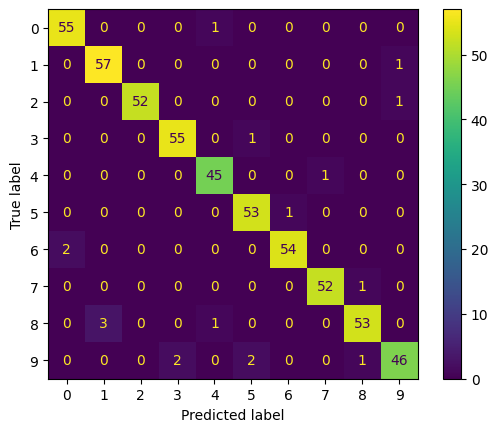

In [14]:
# Matriz de confusión 
#Otra alternativa para analizar el desempeño es la matriz de confusion
#tambien podemos calcularla desde la libreria sklearn
cm_rf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=RF_gridSearch.best_estimator_.classes_)
disp.plot()

### **Optimizacion de hiperparametros usando busqueda aleatoria**

Objetivo: encontrar la mejor combinación de hiperparámetros
para un RandomForestClassifier mediante búsqueda aleatoria
 (RandomizedSearchCV)

In [18]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {'n_estimators': np.arange(10,250,5),
              'criterion': ['gini','entropy'],
              'max_depth': [2,3,5,10,12,15,20]
              }

#Definimos el clasificador base
base_estimator = RandomForestClassifier()
#Seleccionamos los hiperparametros
RF_randomSearch = RandomizedSearchCV(base_estimator,param_grid,n_iter=15)
#Nota: despues de emplear RandomizedSearchVC tambien se requiere entrenar
#el modelo
RF_randomSearch.fit(X_train, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(), n_iter=15,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [2, 3, 5, 10, 12, 15, 20],
                                        'n_estimators': array([ 10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,
        75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125, 130, 135,
       140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200,
       205, 210, 215, 220, 225, 230, 235, 240, 245])})

In [19]:
#Revisamos los parametros seleccionados
RF_randomSearch.best_params_

{'n_estimators': np.int64(145), 'max_depth': 12, 'criterion': 'entropy'}

In [20]:
#Calculamos la precision
y_pred=RF_randomSearch.predict(X_test)
print("Accuracy - Opt", metrics.accuracy_score(y_test,y_pred))

Accuracy - Opt 0.9722222222222222


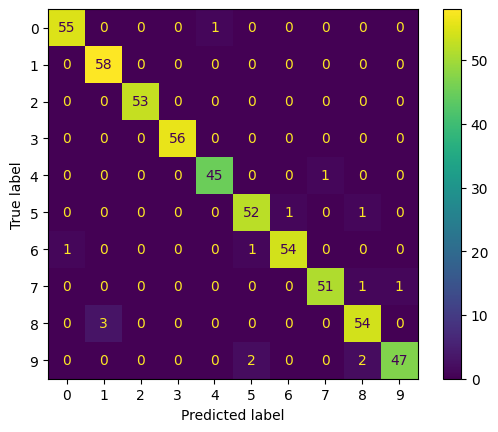

In [21]:
#Calculamos la matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=RF_gridSearch.best_estimator_.classes_)
disp.plot()

### **Optimizacion de hiperparametros usando optimización bayesiana**

Objetivo: encontrar la mejor combinación de hiperparámetros
para un RandomForestClassifier mediante optimización Bayesiana (BayesSearchCV)

In [22]:
#Creamos la grilla con los parametros a seleccionar
param_grid = {'n_estimators':   np.arange(10,250,5),
              'criterion': ['gini','entropy'],
              'max_depth': [2,3,5,10,12,15,20]
}
#Defimos el clasificador base
base_estimator = RandomForestClassifier()
#Realizamos la busqueda de los hiperparametros
###############
RF_optBay = BayesSearchCV(base_estimator,param_grid,n_iter=15)
#Nota: no se olviden de invocar el metodo para entrenar .fit
RF_optBay.fit(X_train,y_train)

BayesSearchCV(estimator=RandomForestClassifier(), n_iter=15,
              search_spaces={'criterion': ['gini', 'entropy'],
                             'max_depth': [2, 3, 5, 10, 12, 15, 20],
                             'n_estimators': array([ 10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,
        75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125, 130, 135,
       140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200,
       205, 210, 215, 220, 225, 230, 235, 240, 245])})

In [23]:
#Revisamos los parametros seleccionados
RF_optBay.best_params_

OrderedDict([('criterion', 'entropy'),
             ('max_depth', 15),
             ('n_estimators', 75)])

In [24]:
#Calculamos la precision
y_pred=RF_optBay.predict(X_test)
print("Accuracy - Opt", metrics.accuracy_score(y_test,y_pred))

Accuracy - Opt 0.9629629629629629


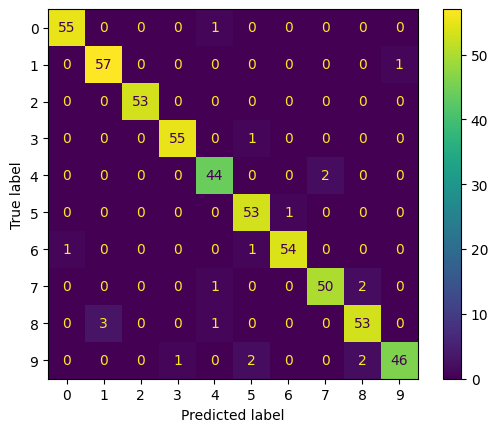

In [25]:
#Calculamos la matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=RF_optBay.best_estimator_.classes_)
disp.plot()

### **Comparación de los parametros obtenidos por los diferentes metodos de optimización.**

In [45]:
print(f"Por el metodo de grilla, aleatorio y bayesiono obtenemos los siguientes parametros optimos\n{RF_gridSearch.best_params_},\
      \n{RF_randomSearch.best_params_} y \n{RF_optBay.best_params_} respectivamente")

Por el metodo de grilla, aleatorio y bayesiono obtenemos los siguientes parametros optimos
{'criterion': 'entropy', 'max_depth': 20, 'n_estimators': np.int64(90)},      
{'n_estimators': np.int64(145), 'max_depth': 12, 'criterion': 'entropy'} y 
OrderedDict({'criterion': 'entropy', 'max_depth': 15, 'n_estimators': 75}) respectivamente


## **Regresión RandonForest sobre el conjunto de datos fetch_california_housing.**

In [4]:
# Cargar la base de datos 
hause = datasets.fetch_california_housing()

# Revisamos categorias y columnas de la base de datos 
print(hause.target_names)
print(hause.feature_names)

['MedHouseVal']
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [5]:
df_hause = pd.DataFrame(data=hause.data, columns=hause.feature_names)
df_hause["MedHouseVa"] = hause.target

df_hause

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVa
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [8]:
# Dividimos los datos entre entrenamiento y prueba 
X = df_hause[df_hause.columns.difference(["MedHouseVa"])]
Y = df_hause.MedHouseVa

# Seleccionamos el conjunto de entrenamiento (70% del total de los datos) y el conjunto de prueba (30% d elos datos)
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **Optimización de hiperparametros usando busqueda de grilla**

Objetivo: encontrar la mejor combinación de hiperparámetros
para un RandomForestRegressor mediante búsqueda exhaustiva
por grilla (GridSearchCV)

In [17]:
#Creamos la grilla con los parametros a seleccionar
param_grid = {'n_estimators': np.arange(10,80,30), ##
              'criterion': ["squared_error","absolute_error"], ##
              'max_depth': [2,5,10] ##
}
#Defimos el modelo base
base_estimator = RandomForestRegressor(random_state=0)
#Realizamos la busqueda de los hiperparametros
RF_gridSearch = GridSearchCV(base_estimator,param_grid,cv=3)
RF_gridSearch.fit(X_train,y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=0),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [2, 5, 10],
                         'n_estimators': array([10, 40, 70])})

In [18]:
# Revisamos los parametros seleccionados 
RF_gridSearch.best_params_

{'criterion': 'absolute_error', 'max_depth': 10, 'n_estimators': np.int64(70)}

In [26]:
# revisamos metricas de desempeño
y_pred = RF_gridSearch.best_estimator_.predict(X_test)
print("Grilla   -> MAE:", metrics.mean_absolute_error(y_test, y_pred),"\n",
      "           MSE:", metrics.mean_squared_error(y_test, y_pred),"\n",
      "           R2:", metrics.r2_score(y_test, y_pred))

Grilla   -> MAE: 0.35209644634782217 
            MSE: 0.2858053919357566 
            R2: 0.7865362582583136


### **Optimizacion de hiperparametros usando busqueda aleatoria**

Objetivo: encontrar la mejor combinación de hiperparámetros
RandomForestRegressor para un  mediante búsqueda aleatoria
 (RandomizedSearchCV)

In [10]:
#Creamos la grilla de hiperparametros, entre las cuales se seleccionara de forma
#aleatoria la mejor configuracion
param_grid = {'n_estimators': np.arange(10,80,20), ##
              'criterion': ["squared_error","absolute_error"], ##
              'max_depth': [2,3,10] ##
}
#Defimos el modelo base
base_estimator = RandomForestRegressor(random_state=0)
#Realizamos la busqueda de los hiperparametros
RF_randomSearch = RandomizedSearchCV(base_estimator,param_grid,n_iter=12)
RF_randomSearch.fit(X_train,y_train)

RandomizedSearchCV(estimator=RandomForestRegressor(random_state=0), n_iter=12,
                   param_distributions={'criterion': ['squared_error',
                                                      'absolute_error'],
                                        'max_depth': [2, 3, 10],
                                        'n_estimators': array([10, 30, 50, 70])})

In [11]:
#Revisamos los parametros seleccionados
RF_randomSearch.best_params_

{'n_estimators': np.int64(70), 'max_depth': 10, 'criterion': 'absolute_error'}

In [12]:
#Evaluamos el desempeño
y_pred = RF_randomSearch.best_estimator_.predict(X_test)
print("MAE: ", metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ", metrics.mean_squared_error(y_test,y_pred))
print("R2:  ", metrics.r2_score(y_test,y_pred))

MAE:  0.35209644634782217
MSE:  0.2858053919357566
R2:   0.7865362582583136


### **Optimizacion de hiperparametros usando Optimización bayesiana**

Objetivo: encontrar la mejor combinación de hiperparámetros
para un RandomForestRegressor mediante búsqueda aleatoria
(BayesSearchCV)

In [14]:
param_grid = {'n_estimators': np.arange(10,80,20), ##
              'criterion': ["squared_error","absolute_error"], ##
              'max_depth': [2,3,5,10] ##
}
#Defimos el modelo base
base_estimator = RandomForestRegressor(random_state=0)
#Realizamos la busqueda de los hiperparametros
RF_optBay = BayesSearchCV(base_estimator,param_grid,n_iter=12,cv=3)
#Nota: no se olviden de invocar el metodo para entrenar .fit
RF_optBay.fit(X_train,y_train)

BayesSearchCV(cv=3, estimator=RandomForestRegressor(random_state=0), n_iter=12,
              search_spaces={'criterion': ['squared_error', 'absolute_error'],
                             'max_depth': [2, 3, 5, 10],
                             'n_estimators': array([10, 30, 50, 70])})

In [15]:
RF_optBay.best_params_

OrderedDict([('criterion', 'absolute_error'),
             ('max_depth', 10),
             ('n_estimators', 30)])

In [16]:
#Evaluamos el desempeño
y_pred = RF_optBay.best_estimator_.predict(X_test)
print("MAE: ", metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ", metrics.mean_squared_error(y_test,y_pred))
print("R2:  ", metrics.r2_score(y_test,y_pred))

MAE:  0.35314300710594315
MSE:  0.2867713621672578
R2:   0.7858147896441957



Notas:

Los resultas obtenidos por los diferentes metodos de optimización arrojan resultados en las metricas de precisión muy parecidos, aunque algunos de ellos encontraron parámetros optimos diferentes.